In [1]:
# Plot sensing line for real copepods in turbulence with real preys

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

In [3]:
# Data
NPoints = 80 # Grid number of points per axis
NTrials = 30 # Number of trial x point

AntennaeLength = .01 # Sensors distance, on antennae, 10 mm
x = np.linspace(0.1, 5, NPoints) # x axis
z = np.linspace(0.1, 5, NPoints) # z axis

e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
roll = .4 # Roll Intensity

In [4]:
# Typical velocity magnitude generated by a prey at distance l
# U a ^2 / l^2
# Typical gradient sensed
# U a^2 / d^3 
# Typical values for turbulence
PreySize = 1e-4 # 100 micrometer 
SpeedSize = 1e-3 # 1 mm/s

In [5]:
#Paper 1 10.1098/rsbl.2011.1073 
PointsPrey_pp1 = [
    [0.2896810506566604, 0.11344792107970725],
    [0.5195121951219512, 0.07193608908793836],
    [0.33893058161350836, 0.6038612842704109],
    [0.4013133208255158, 0.5652665980754098],
    [0.7362101313320828, 0.5465290806754224],
    [0.9955909943714825, 0.627652363372269],
    [0.9594746716697937, 0.7469406282152152],
    [0.8314258911819891, 0.998317496822611],
    [0.906941838649156, 1.1049083096290022],
    [1.084240150093809, 0.9503964171155359],
    [1.327204502814259, 0.9185862131574172],
    [1.9772983114446536, 0.2415057798220661],
    [1.360037523452158, 0.23619197482297394],
    [0.9660412757973735, 0.014694668038492065],
    [0.13536585365853643, 0.038449434122132864],
    [0.19774859287054408, 0.4609150880590691],
    [0.7263602251407131, 0.38897294680142847],
    [0.7854596622889308, 0.6275736851661322],
    [0.12879924953095653, 0.744913151364764],
    [0.04671669793620971, 0.8321612298008836],
    [0.31594746716697913, 0.9123101131755733]
]


In [6]:
PointsPrey_pp2 = [
    [0.30531561461794016, 0.45568727742058873],
    [0.4408637873754152, 0.14585673653768055],
    [0.4103654485049833, 0.20295657161978053],
    [0.3493687707641193, 0.30705800807858685],
    [0.31548172757475074, 0.3033413800521044],
    [0.10877076411960114, 0.2522526829035111],
    [0.15960132890365458, 0.3711369774612203],
    [0.1562126245847174, 0.46105308444274484],
    [0.020664451827242355, 0.406618227013074],
    [0.013887043189368498, 0.30947202370993576],
    [0.01727574750830545, 0.7519300174478358],
    [0.11554817275747538, 0.6551542818901026],
    [0.35275747508305677, 0.749516001816487],
    [0.9356146179401995, 0.2084060326489635],
    [0.9288372093023256, 0.1436339300652499],
    [1.0271096345514952, 0.06124668371614968],
    [1.0304983388704319, 0.057446401682640875],
    [1.0271096345514952, 0.13659504290255559],
    [0.39342192691029887, 0.008652214441071487],
    [0.7458471760797342, 0.15377996606037395],
    [0.6950166112956812, 0.2507230096321611],
    [0.2985382059800661, 0.4687492530892229],
    [0.10877076411960114, 0.16232462534955425],
    [0.10877076411960114, 0.046308468175625776]
]


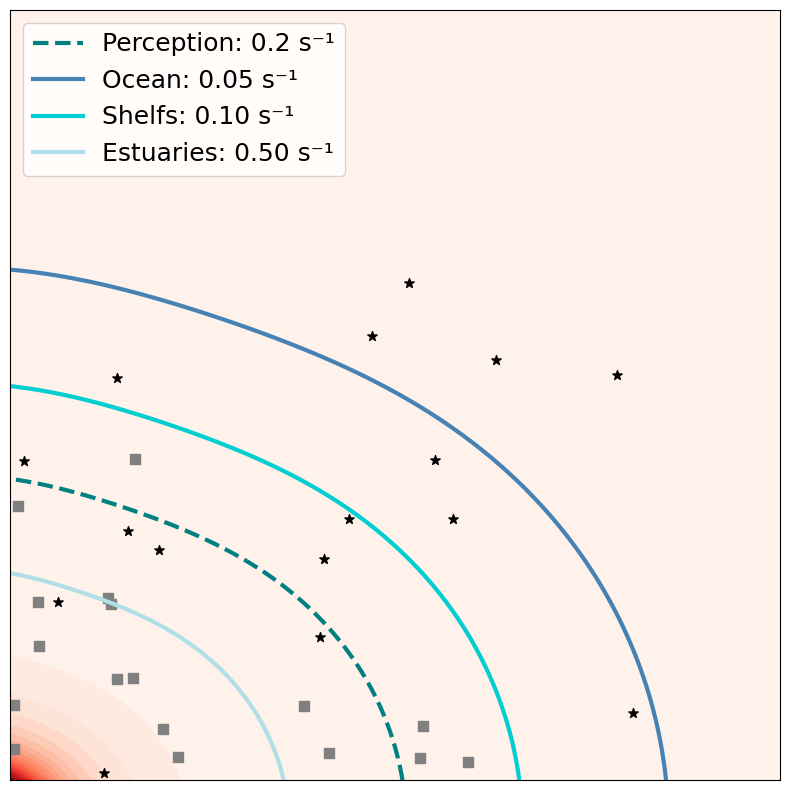

In [8]:

def GradientStresslet(e, x):
    r = np.linalg.norm(x) 
    gradflow = np.eye(3)/r**3 - 3*np.outer(x, x)/r**5 - 6*np.dot(x, e)*np.outer(x, e)/r**5 - 3*np.dot(x, e)**2*np.eye(3)/r**5 + 15*np.dot(x, e)**2*np.outer(x, x)/r**7    
    return -gradflow
    
# Parameters
U = 1e-3           # Prey swimming speed [m/s]
a = 1e-4           # Prey size [m]
threshold = 0.2   # Copepod strain rate sensitivity [1/s]
TurbulenceOcean = 0.5e-1
TurbulenceShelfs = 1e-1
TurbulenceEstuaries = 0.5
NPoints = 300

# Define velocity gradient magnitude from stresslet
def grad_u(U, a, z, x):
    e3 = np.array([1.0, 0, 0])
    return 3*U*a**2*np.linalg.norm(GradientStresslet(e3, np.array([z, x, 0.0])))

# Compute detection distance
l_threshold = (U * a**2 / threshold) ** (1/3)

# Grid (only first quadrant)
z = np.linspace(a, 4.5 * l_threshold, NPoints)
x = np.linspace(a, 4.5 * l_threshold, NPoints)
Z, X = np.meshgrid(z, x)
strain_rate = np.zeros_like(Z)

for k in range(NPoints):
    for i in range(NPoints):
        strain_rate[k, i] = grad_u(U, a, Z[k, i], X[k, i])

# Plot contour
plt.figure(figsize=(8, 8))
cp = plt.contourf(Z * 1e3, X * 1e3, strain_rate, levels=30, cmap="Reds")
#cbar = plt.colorbar(cp, label="|∇u| [1/s]")

# Highlight the threshold contour
contour_threshold = plt.contour(Z * 1e3, X * 1e3, strain_rate, levels=[threshold], colors='teal', linewidths=3, linestyles = '--')
contour = plt.contour(Z * 1e3, X * 1e3, strain_rate, levels=[TurbulenceOcean], colors='steelblue', linewidths=3)
contour = plt.contour(Z * 1e3, X * 1e3, strain_rate, levels=[TurbulenceShelfs], colors='darkturquoise', linewidths=3)
contour = plt.contour(Z * 1e3, X * 1e3, strain_rate, levels=[TurbulenceEstuaries], colors='powderblue', linewidths=3)

# Create legend handles
handles = [
    plt.Line2D([], [], color='teal', linestyle='--', linewidth=3, label=f'Perception: {threshold:.1f} s⁻¹'),
    plt.Line2D([], [], color='steelblue', linewidth=3, label=f'Ocean: {TurbulenceOcean:.2f} s⁻¹'),
    plt.Line2D([], [], color='darkturquoise', linewidth=3, label=f'Shelfs: {TurbulenceShelfs:.2f} s⁻¹'),
    plt.Line2D([], [], color='powderblue', linewidth=3, label=f'Estuaries: {TurbulenceEstuaries:.2f} s⁻¹')
]
plt.legend(handles=handles, loc='upper left', frameon=True, fontsize=18)

# Add points prey
# Convert to numpy array
points_pp1 = np.array(PointsPrey_pp1)
points_pp2 = np.array(PointsPrey_pp2)

# Create scatter plot
plt.scatter(points_pp1[:, 0], points_pp1[:, 1], color='black', marker = '*', s=50)
plt.scatter(points_pp2[:, 0], points_pp2[:, 1], color='grey', marker = 's', s=50)

# Labels and plot settings
plt.xlim(a * 1e3, 4.5 * l_threshold * 1e3+ 1e-5)
plt.ylim(a * 1e3, 4.5 * l_threshold * 1e3+ 1e-5)
plt.xticks([])
plt.yticks([])
plt.grid(True, linestyle='-', alpha=0.4) 
plt.tight_layout()
plt.savefig("./ThresholdLevelTurbulenceSensitivity.pdf")
plt.show()


# For the prey

C:\Users\Redaelli\AppData\Local\Temp\ipykernel_38908\1752828475.py:89: UserWarning: The following kwargs were not used by contour: 'label'
  contour_thresholdV = ax.contour(Z, X, DIST, levels=[DistMateSensory], colors=SENSORYCOLOR, linewidths=5, label=fr'$r_{{\rm sensory}}$: {DistMateSensory:.2f} mm')
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_38908\1752828475.py:90: UserWarning: The following kwargs were not used by contour: 'label'
  contour_oceanV = ax.contour(Z, X, DIST, levels=[DistMateTurbulence], colors=FLOWCOLOR, linewidths=5, label=fr'$r_{{\rm turbulence}}$: {DistMateTurbulence:.2f} mm')
C:\Users\Redaelli\AppData\Local\Temp\ipykernel_38908\1752828475.py:91: UserWarning: The following kwargs were not used by contour: 'label'
  contour_experimentalV2 = ax.contour(Z, X, DIST, levels=[MeanDistances_pp2], colors='darkgrey', linewidths=2, linestyles = 'dashdot', label=f'Experimental data')
findfont: Generic family 'serif' not found because none of the following families were fou

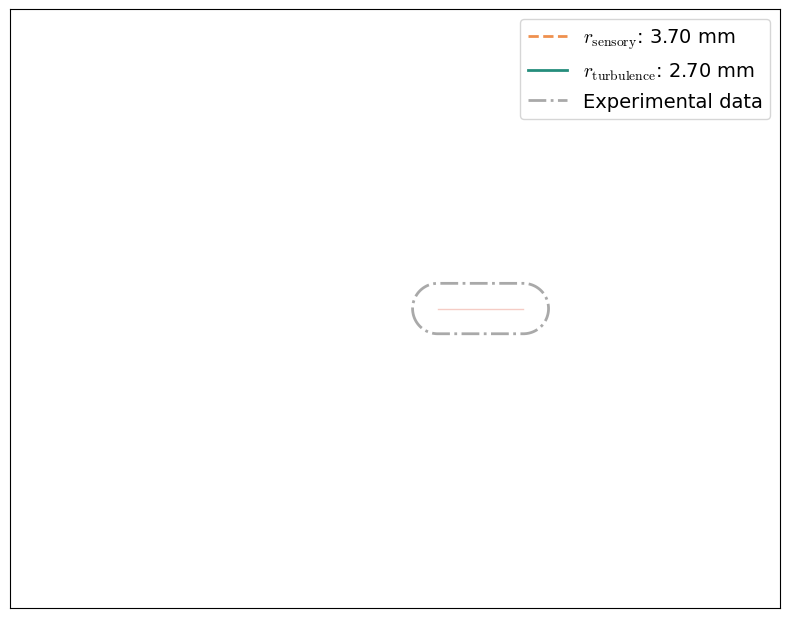

In [59]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",   # let matplotlib choose
    "mathtext.fontset": "cm", # Computer Modern for math
})
# calculate mean distances from data from papers
MeanDistances_pp1 = np.mean(points_pp1[:,1]) # take only y axis
MeanDistances_pp2 = np.mean(points_pp2[:,1]) # take only y axis
# Parameters

segment_start = np.array([-0.5, 0])
segment_end = np.array([0.5, 0])

threshold = 0.2    # Copepod strain rate sensitivity [1/s]
TurbulenceOcean = 0.5e-1
TurbulenceShelfs = 1e-1
TurbulenceEstuaries = 0.5

def DefDistance(U, a, mu, noise, Antenna = 1e-3):
    return (3*U*a**2/mu/noise)**(1/3)

def DefDistanceVissier(U, a, noise, AntennaeLenght = 1e-3):
    return a*(3*U/(noise*AntennaeLenght))**(1/2)*1000

def DefDistanceVissierPredator(U, a, noise, AntennaeLenght = 1e-3):
    return (6*U*a**2*AntennaeLenght/(noise*AntennaeLenght))**(1/3)*1000
    
U = 1e-3
Up = 1e-3
ap = 1e-2
a = 1e-4
mu = 1e-6
#DistThreshold = DefDistance(U, a, mu, threshold)
#Dist_Ocean = DefDistance(U, a, mu, TurbulenceOcean)
#DistShelfs = DefDistance(U, a, mu, TurbulenceShelfs) 
#DistEstuaries = DefDistance(U, a, mu, TurbulenceEstuaries)

PREDATOR_COLOR = "#DE5840"
PREDATOR_COLOR = to_rgba(PREDATOR_COLOR, alpha=0.3)

#DistThresholdV = DefDistanceVissier(U, a, threshold)
#Dist_OceanV = DefDistanceVissier(U, a, TurbulenceOcean)
#DistShelfsV = DefDistanceVissier(U, a, TurbulenceShelfs) 
#DistEstuariesV = DefDistanceVissier(U, a, TurbulenceEstuaries)
#DistPredatorV = DefDistanceVissierPredator(Up, ap, threshold)

DistPreySensory = 0.42
DistMateSensory = 3.7

DistPreyTurbulence = 0.14
DistMateTurbulence = 2.7
# Function to compute distance from a point to the segment
def distance_to_segment(px, py, a, b):
    ap = np.array([px, py]) - a
    ab = b - a
    t = np.clip(np.dot(ap, ab) / np.dot(ab, ab), 0, 1)
    closest = a + t * ab
    return np.linalg.norm(np.array([px, py]) - closest)

# Create grid
x = np.linspace(-2, 2, 500)
z = np.linspace(-2, 2, 500)
X, Z = np.meshgrid(x, z)

# Compute distances
DIST = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        DIST[i, j] = distance_to_segment(Z[i, j], X[i, j], segment_start, segment_end)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([-0.5, 0.5], [0, 0], c = PREDATOR_COLOR, lw=1)  # the segment

ax.set_aspect('equal')
ax.set_xlim(-5.5, 3.5)
ax.set_ylim(-3.5, 3.5)

# Highlight the threshold contour
#contour_threshold = ax.contour(Z, X, DIST, levels=[DistThreshold], colors='teal', linewidths=3, linestyles='--')
#contour_ocean = ax.contour(Z, X, DIST, levels=[Dist_Ocean], colors='steelblue', linewidths=3)
#contour_shelfs = ax.contour(Z, X, DIST, levels=[DistShelfs], colors='darkturquoise', linewidths=3)
#contour_estuaries = ax.contour(Z, X, DIST, levels=[DistEstuaries], colors='powderblue', linewidths=3)
SENSORYCOLOR  = '#EF904E'
FLOWCOLOR = '#258D7C'

contour_thresholdV = ax.contour(Z, X, DIST, levels=[DistMateSensory], colors=SENSORYCOLOR, linewidths=5, label=fr'$r_{{\rm sensory}}$: {DistMateSensory:.2f} mm')
contour_oceanV = ax.contour(Z, X, DIST, levels=[DistMateTurbulence], colors=FLOWCOLOR, linewidths=5, label=fr'$r_{{\rm turbulence}}$: {DistMateTurbulence:.2f} mm')
contour_experimentalV2 = ax.contour(Z, X, DIST, levels=[MeanDistances_pp2], colors='darkgrey', linewidths=2, linestyles = 'dashdot', label=f'Experimental data')

# Define custom legend handles
handles = [
    plt.Line2D([], [], color=SENSORYCOLOR, linewidth=2, linestyle = '--', label=fr'$r_{{\rm sensory}}$: {DistMateSensory:.2f} mm'),
    plt.Line2D([], [], color=FLOWCOLOR, linewidth=2, label=fr'$r_{{\rm turbulence}}$: {DistMateTurbulence:.2f} mm'),
    plt.Line2D([], [], color='darkgrey', linewidth=2, linestyle = '-.', label=f'Experimental data')#,plt.Line2D([], [], color='red', linewidth=3, label=f'Predator')
]

# Now add the legend properly to the ax
ax.legend(handles = handles, loc='upper right', frameon=True, fontsize=14)
plt.xticks([])
plt.yticks([])
#plt.grid(True, linestyle='-', alpha=0.4) 
plt.tight_layout()
plt.grid(True, linestyle='-', alpha=0.4)
plt.savefig("./ThresholdLevelTurbulenceSensitivityAntennaCentered_mate.pdf")
plt.show()


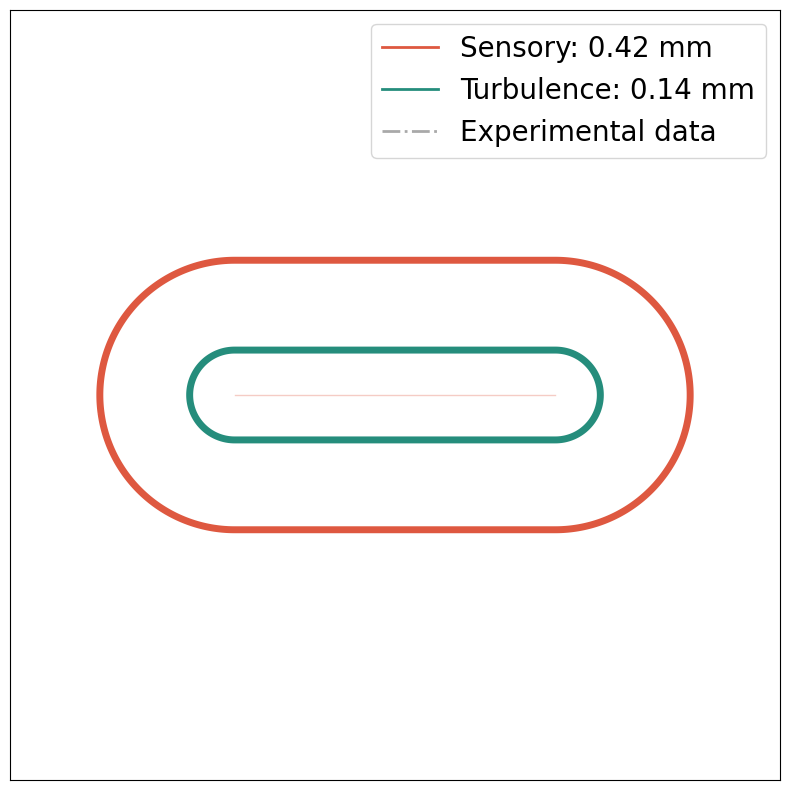

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- RESET TO STANDARD MATPLOTLIB DEFAULTS (NO LaTeX, NO FONT ISSUES) ----
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",   # default: DejaVu Sans
})

# ------------------------------------------------------------------------

# calculate mean distances from data from papers
MeanDistances_pp1 = np.mean(points_pp1[:, 1])  # take only y axis
MeanDistances_pp2 = np.mean(points_pp2[:, 1])  # take only y axis

# Parameters
segment_start = np.array([-0.5, 0])
segment_end   = np.array([0.5, 0])

threshold = 0.2
TurbulenceOcean = 0.5e-1
TurbulenceShelfs = 1e-1
TurbulenceEstuaries = 0.5

def DefDistance(U, a, mu, noise, Antenna=1e-3):
    return (3 * U * a**2 / mu / noise) ** (1/3)

def DefDistanceVissier(U, a, noise, AntennaeLenght=1e-3):
    return a * (3 * U / (noise * AntennaeLenght)) ** (1/2) * 1000

def DefDistanceVissierPredator(U, a, noise, AntennaeLenght=1e-3):
    return (6 * U * a**2 * AntennaeLenght / noise) ** (1/3) * 1000

U = 1e-3
Up = 1e-3
ap = 1e-2
a  = 1e-4
mu = 1e-6

PREDATOR_COLOR = to_rgba("#DE5840", alpha=0.3)

DistPreySensory = 0.42
DistMateSensory = 3.7
DistPreyTurbulence = 0.14
DistMateTurbulence = 2.7

# Distance to line segment
def distance_to_segment(px, py, a, b):
    ap = np.array([px, py]) - a
    ab = b - a
    t = np.clip(np.dot(ap, ab) / np.dot(ab, ab), 0, 1)
    closest = a + t * ab
    return np.linalg.norm(np.array([px, py]) - closest)

# Grid
x = np.linspace(-1.2, 1.2, 500)
z = np.linspace(-1.2, 1.2, 500)
X, Z = np.meshgrid(x, z)

DIST = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        DIST[i, j] = distance_to_segment(Z[i, j], X[i, j],
                                         segment_start, segment_end)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([-0.5, 0.5], [0, 0], color=PREDATOR_COLOR, lw=1)

ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

SENSORYCOLOR = '#DE5840'
FLOWCOLOR    = '#258D7C'

ax.contour(Z, X, DIST, levels=[DistPreySensory],
           colors=SENSORYCOLOR, linewidths=5)

ax.contour(Z, X, DIST, levels=[DistPreyTurbulence],
           colors=FLOWCOLOR, linewidths=5)

#ax.contour(Z, X, DIST, levels=[MeanDistances_pp2],
#           colors='darkgrey', linewidths=2, linestyles='dashdot')

# Legend
handles = [
    plt.Line2D([], [], color=SENSORYCOLOR, lw=2, linestyle='-',
               label=f'Sensory: {DistPreySensory:.2f} mm'),
    plt.Line2D([], [], color=FLOWCOLOR, lw=2,
               label=fr'Turbulence: {DistPreyTurbulence:.2f} mm'),
    plt.Line2D([], [], color='darkgrey', lw=2, linestyle='-.',
               label='Experimental data'),
]

ax.legend(handles=handles, loc='upper right', frameon=True, fontsize=20)

ax.set_xticks([])
ax.set_yticks([])
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("ThresholdLevelTurbulenceSensitivityAntennaCentered_prey.pdf",
            dpi=300, bbox_inches="tight")
plt.show()


# For the predator

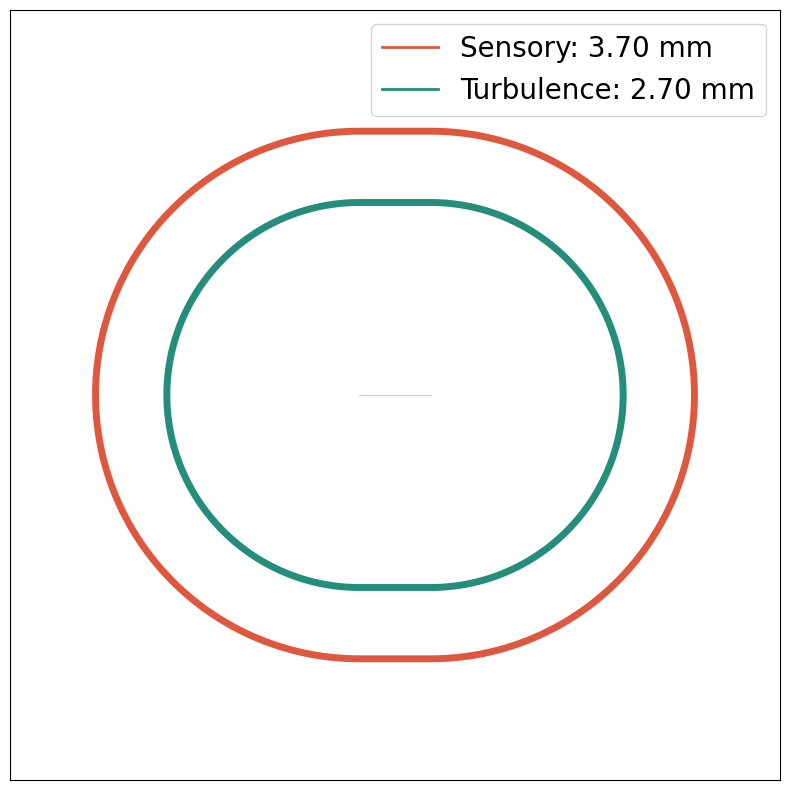

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- RESET TO STANDARD MATPLOTLIB DEFAULTS (NO LaTeX, NO FONT ISSUES) ----
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",   # default: DejaVu Sans
})

# ------------------------------------------------------------------------

# calculate mean distances from data from papers
MeanDistances_pp1 = np.mean(points_pp1[:, 1])  # take only y axis
MeanDistances_pp2 = np.mean(points_pp2[:, 1])  # take only y axis

# Parameters
segment_start = np.array([-0.5, 0])
segment_end   = np.array([0.5, 0])

threshold = 0.2
TurbulenceOcean = 0.5e-1
TurbulenceShelfs = 1e-1
TurbulenceEstuaries = 0.5

def DefDistance(U, a, mu, noise, Antenna=1e-3):
    return (3 * U * a**2 / mu / noise) ** (1/3)

def DefDistanceVissier(U, a, noise, AntennaeLenght=1e-3):
    return a * (3 * U / (noise * AntennaeLenght)) ** (1/2) * 1000

def DefDistanceVissierPredator(U, a, noise, AntennaeLenght=1e-3):
    return (6 * U * a**2 * AntennaeLenght / noise) ** (1/3) * 1000

U = 1e-3
Up = 1e-3
ap = 1e-2
a  = 1e-4
mu = 1e-6

PREDATOR_COLOR = to_rgba("#DE5840", alpha=0.3)

DistPreySensory = 0.42
DistMateSensory = 3.7
DistPreyTurbulence = 0.14
DistMateTurbulence = 2.7

# Distance to line segment
def distance_to_segment(px, py, a, b):
    ap = np.array([px, py]) - a
    ab = b - a
    t = np.clip(np.dot(ap, ab) / np.dot(ab, ab), 0, 1)
    closest = a + t * ab
    return np.linalg.norm(np.array([px, py]) - closest)

# Grid
x = np.linspace(-5.2, 5.2, 500)
z = np.linspace(-5.2, 5.2, 500)
X, Z = np.meshgrid(x, z)

DIST = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        DIST[i, j] = distance_to_segment(Z[i, j], X[i, j],
                                         segment_start, segment_end)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([-0.5, 0.5], [0, 0], color=PREDATOR_COLOR, lw=1)

ax.set_aspect('equal')
ax.set_xlim(-5.4, 5.4)
ax.set_ylim(-5.4, 5.4)

SENSORYCOLOR = '#DE5840'
FLOWCOLOR    = '#258D7C'

ax.contour(Z, X, DIST, levels=[DistMateSensory],
           colors=SENSORYCOLOR, linewidths=5)

ax.contour(Z, X, DIST, levels=[DistMateTurbulence],
           colors=FLOWCOLOR, linewidths=5)

#ax.contour(Z, X, DIST, levels=[MeanDistances_pp2],
#           colors='darkgrey', linewidths=2, linestyles='dashdot')

# Legend
handles = [
    plt.Line2D([], [], color=SENSORYCOLOR, lw=2, linestyle='-',
               label=f'Sensory: {DistMateSensory:.2f} mm'),
    plt.Line2D([], [], color=FLOWCOLOR, lw=2,
               label=fr'Turbulence: {DistMateTurbulence:.2f} mm'),
    #plt.Line2D([], [], color='darkgrey', lw=2, linestyle='-.',
    #           label='Experimental data'),
]

ax.legend(handles=handles, loc='upper right', frameon=True, fontsize=20)

ax.set_xticks([])
ax.set_yticks([])
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("ThresholdLevelTurbulenceSensitivityAntennaCentered_mate.pdf",
            dpi=300, bbox_inches="tight")
plt.show()
